Data successfully loaded and cleaned!
Dataset Shape: 541 patients, 42 features.

Top 10 Features by Mutual Information:
 1. Follicle No. (R)          (Score: 0.2400)
 2. Follicle No. (L)          (Score: 0.2036)
 3. Skin darkening (Y/N)      (Score: 0.1289)
 4. hair growth(Y/N)          (Score: 0.1021)
 5. Weight gain(Y/N)          (Score: 0.0879)
 6. Cycle(R/I)                (Score: 0.0775)
 7. Cycle length(days)        (Score: 0.0740)
 8. AMH(ng/mL)                (Score: 0.0727)
 9. PRL(ng/mL)                (Score: 0.0663)
 10. FSH/LH                    (Score: 0.0653)


Generated and saved 'top_10_features_boxplots.png' successfully.



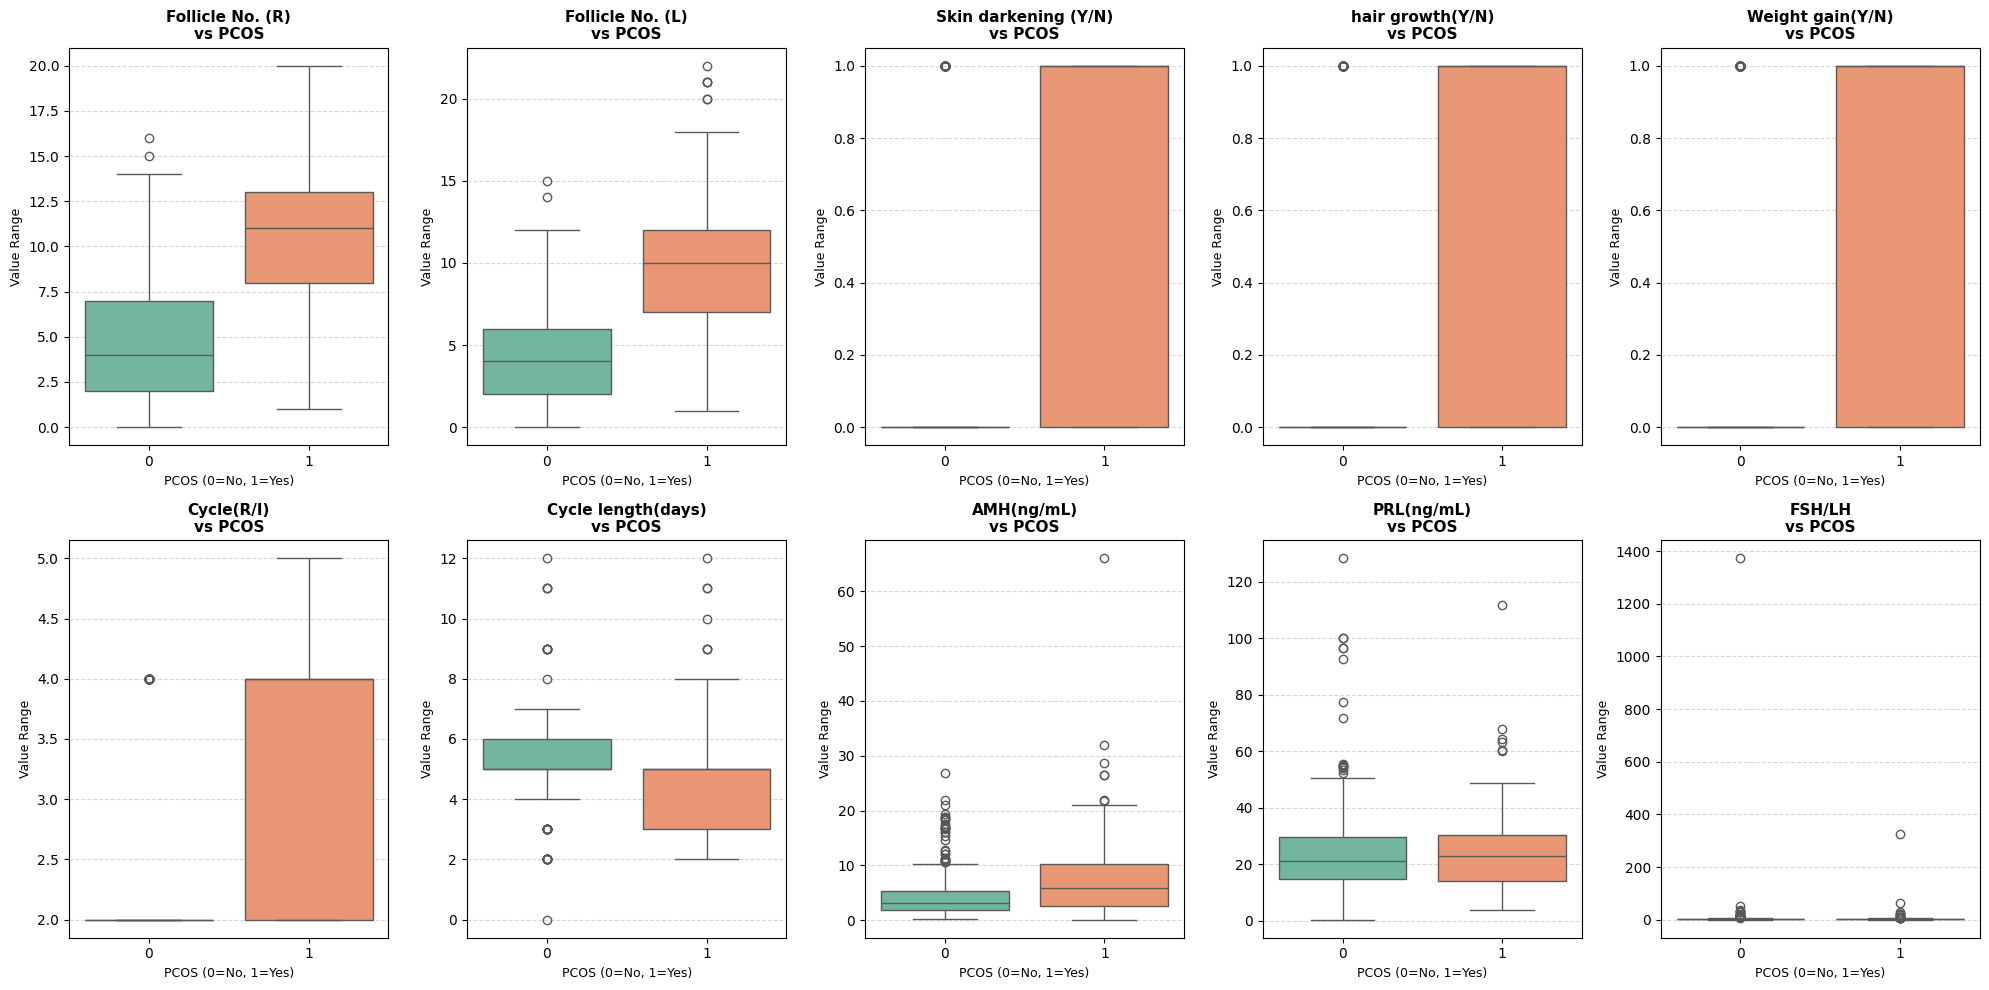

Final Cross-Validated Architecture Baselines:
-----------------------------------------------------------------
Metric          | Logistic Regression (Scaled)   | Random Forest  
-----------------------------------------------------------------
Accuracy        | 0.8834                           | 0.8706
Sensitivity     | 0.8140                           | 0.7181
Specificity     | 0.9175                           | 0.9450
AUC-ROC         | 0.9382                           | 0.9349
-----------------------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer


# LOAD & CLEAN
file_path = r'#insert path file here' #insert file path
df = pd.read_excel(file_path, engine='openpyxl', sheet_name='Full_new')

# Strip trailing/leading whitespaces from column names to eliminate KeyErrors
df.columns = df.columns.str.strip()

# Drop identifiers safely
cols_to_drop = ['Sl. No', 'Patient File No.']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Coerce known dirty clinical text entries (like the letter 'a' in AMH) to numeric NaNs
dirty_numeric_cols = ['AMH(ng/mL)', 'II    beta-HCG(mIU/mL)']
for col in dirty_numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Exclude any remaining unhandled text columns
df = df.select_dtypes(exclude=['object'])

# Fill NaNs using the column medians (safest choice for medical outlier ranges)
df.fillna(df.median(), inplace=True)

print("Data successfully loaded and cleaned!")
print(f"Dataset Shape: {df.shape[0]} patients, {df.shape[1]} features.\n")


# MUTUAL INFORMATION SCORES
target = 'PCOS (Y/N)'
X = df.drop(target, axis=1)
y = df[target]

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Top 10 Features by Mutual Information:")
top_10_features = mi_results.head(10).index.tolist()
for rank, (feature, score) in enumerate(mi_results.head(10).items(), 1):
    print(f" {rank}. {feature:<25} (Score: {score:.4f})")
print("\n")

# EDA: TOP 10 DISTRIBUTIONS VISUALIZATION
plt.figure(figsize=(20, 10))
for i, col in enumerate(top_10_features):
    plt.subplot(2, 5, i + 1)
    
    # Plot boxplot split by PCOS status
    sns.boxplot(x=target, y=col, data=df, palette='Set2', hue=target, legend=False)
    
    plt.title(f'{col}\nvs PCOS', fontsize=11, fontweight='bold')
    plt.xlabel('PCOS (0=No, 1=Yes)', fontsize=9)
    plt.ylabel('Value Range', fontsize=9)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('top_10_features_boxplots.png', dpi=300)
print("Generated and saved 'top_10_features_boxplots.png' successfully.\n")
plt.show()


# BASELINE MODELLING VIA ROBUST PIPELINES
# Custom Scorer for Specificity (True Negative Rate)
def specificity_score(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tn / (tn + fp) if (tn + fp) > 0 else 0

scoring_metrics = {
    'accuracy': 'accuracy',
    'sensitivity': 'recall',
    'specificity': make_scorer(specificity_score),
    'auc': 'roc_auc'
}

# Pipeline 1: Scaler + Logistic Regression (Fixes Convergence Warnings)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline 2: Random Forest (Tree models don't scale-depend, but pipeline keeps it structural)
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Run 5-Fold Stratified Cross-Validation on the full feature set
lr_cv = cross_validate(lr_pipeline, X, y, cv=5, scoring=scoring_metrics)
rf_cv = cross_validate(rf_pipeline, X, y, cv=5, scoring=scoring_metrics)


# OUTPUT METRICS SUMMARY
print("Final Cross-Validated Architecture Baselines:")
print("-" * 65)
print(f"{'Metric':<15} | {'Logistic Regression (Scaled)':<30} | {'Random Forest':<15}")
print("-" * 65)
print(f"{'Accuracy':<15} | {lr_cv['test_accuracy'].mean():.4f}     "
      f"                      | {rf_cv['test_accuracy'].mean():.4f}")
print(f"{'Sensitivity':<15} | {lr_cv['test_sensitivity'].mean():.4f}    "
      f"                       | {rf_cv['test_sensitivity'].mean():.4f}")
print(f"{'Specificity':<15} | {lr_cv['test_specificity'].mean():.4f}    "
      f"                       | {rf_cv['test_specificity'].mean():.4f}")
print(f"{'AUC-ROC':<15} | {lr_cv['test_auc'].mean():.4f}            "
      f"               | {rf_cv['test_auc'].mean():.4f}")
print("-" * 65)